In [2]:
# 1. Paradigm Decision Function

def choose_paradigm(has_labels: bool, goal: str) -> str:
    if has_labels:
        if goal == "predict_category":
            return "Classification"
        elif goal == "predict_number":
            return "Regression"
    else:
        if goal == "discover_groups":
            return "Clustering"
        elif goal == "compress_data":
            return "Dimensionality Reduction"
    return "Unknown"


print("Paradigm Decision:")
tests = [
    (True, "predict_category"),
    (True, "predict_number"),
    (False, "discover_groups"),
    (False, "compress_data"),
]

for has_labels, goal in tests:
    result = choose_paradigm(has_labels, goal)
    print(f"has_labels={has_labels}, goal='{goal}' → {result}")

print()

Paradigm Decision:
has_labels=True, goal='predict_category' → Classification
has_labels=True, goal='predict_number' → Regression
has_labels=False, goal='discover_groups' → Clustering
has_labels=False, goal='compress_data' → Dimensionality Reduction



In [4]:
# 2. Supervised Classification Task
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

print("Supervised: KNN on Digits Dataset")

# Load dataset
data = load_digits()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)\n")

# Classification report
print("Classification Report:")
report = classification_report(y_test, y_pred)
print(report)

# Find lowest precision class
report_dict = classification_report(y_test, y_pred, output_dict=True)
precisions = {int(k): v["precision"] for k, v in report_dict.items() if k.isdigit()}
lowest_class = min(precisions, key=precisions.get)

print(f"Lowest precision digit: {lowest_class} ({precisions[lowest_class]:.2f})")
print()


Supervised: KNN on Digits Dataset
Train size: 1437 | Test size: 360
Test Accuracy: 0.9750 (97.5%)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       0.97      1.00      0.99        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.96      0.96      0.96        47
           6       0.97      1.00      0.99        35
           7       1.00      0.94      0.97        34
           8       0.97      1.00      0.98        30
           9       0.95      0.90      0.92        40

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.97       360

Lowest precision digit: 9 (0.95)



Unsupervised: KMeans on Digits (No Labels)
Cluster sizes: [176, 179, 89, 226, 198, 182, 181, 157, 241, 168]
Largest cluster: Cluster 8 (241 samples)


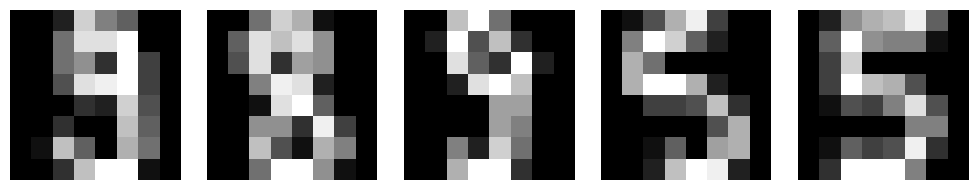

[Saved digit_clusters.png]


In [5]:
# 3. Unsupervised Clustering Task
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import random

print("Unsupervised: KMeans on Digits (No Labels)")

X_unlabeled = data.data

# KMeans
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_unlabeled)

# Cluster sizes
counts = np.bincount(cluster_labels)
print("Cluster sizes:", counts.tolist())

# Largest cluster
largest_cluster = np.argmax(counts)
print(f"Largest cluster: Cluster {largest_cluster} ({counts[largest_cluster]} samples)")

# Get indices of that cluster
indices = np.where(cluster_labels == largest_cluster)[0]

# Pick 5 random samples
samples = random.sample(list(indices), 5)

# Plot images
plt.figure(figsize=(10, 2))
for i, idx in enumerate(samples):
    plt.subplot(1, 5, i + 1)
    plt.imshow(data.images[idx], cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.savefig("digit_clusters.png")
plt.show()

print("[Saved digit_clusters.png]")




# 4. Comparison Analysis (Comments)

Comparison Analysis:

1. Did KMeans clusters perfectly match digit classes?
No, they did not perfectly match.

* Reason:
    * KMeans groups data based on similarity (distance), not true labels.
    * Some digits look similar (e.g., 3, 8, 9), so they may end up in the same cluster.
    * Also, cluster labels (0–9) are arbitrary and do not correspond to digit labels.

2. What does supervised classification give that clustering cannot?
Supervised learning gives:
    - Exact predictions (correct digit labels)
    - Accuracy measurement
    - Detailed metrics (precision, recall, F1-score)

It learns from labeled data, so it knows the "correct answer".

3. What can clustering tell that supervised cannot?
Clustering can:
    - Discover hidden patterns in unlabeled data
    - Group similar images automatically
    - Reveal structure without needing labels

This is useful when labels are unavailable or unknown.